# Testing and Evaluation Notebook
This notebook runs testing and evaluation metrics for the CLIR News Retrieval System. It focuses on data validation, pipeline checks, and standard IR metrics, and produces report artifacts in Module D.

## 1. Import Testing, Metrics, and Reporting Libraries

In [2]:
pip install pytest


   ---------------------------------------- 0/3 [pluggy]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   ---------------------------------------- 3/3 [pytest]

Note: you may need to restart the kernel to use updated packages.


In [3]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Testing
import pytest

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.calibration import calibration_curve
from scipy import stats

# Notebook assembly
import nbformat as nbf

# Project evaluation utilities (if available)
try:
    from evaluation_metrics import (
        mean_average_precision,
        ndcg_at_k,
    )
except Exception:
    mean_average_precision = None
    ndcg_at_k = None

## 2. Discover Test Data and Labels from Module D
Load datasets, predictions, and labels from Module D, and validate that expected files and columns exist.

In [5]:
print(labels_df.columns.tolist())

['query_id', 'query_text', 'doc_id', 'doc_title', 'doc_url', 'language', 'relevant', 'confidence', 'annotator', 'notes']


In [7]:
MODULE_D_NAME = "Module D — Ranking, Scoring, & Evaluation"
MODULE_D_DIR = Path.cwd().resolve()

if MODULE_D_DIR.name != MODULE_D_NAME:
    for parent in MODULE_D_DIR.parents:
        if parent.name == MODULE_D_NAME:
            MODULE_D_DIR = parent
            break

if MODULE_D_DIR.name != MODULE_D_NAME:
    print("Warning: Module D directory not found; using:", MODULE_D_DIR)

DATA_FILES = {
    "demo_labels": MODULE_D_DIR / "demo_labels.csv",
    "test_queries": MODULE_D_DIR / "test_queries.json",
    "evaluation_results": MODULE_D_DIR / "evaluation_results.json",
}

missing = [name for name, path in DATA_FILES.items() if not path.exists()]
print("Missing files:", missing)

labels_df = None
if DATA_FILES["demo_labels"].exists():
    labels_df = pd.read_csv(DATA_FILES["demo_labels"])
    print(labels_df.head())

queries = None
if DATA_FILES["test_queries"].exists():
    with open(DATA_FILES["test_queries"], "r", encoding="utf-8") as f:
        queries = json.load(f)
    print("Loaded queries:", len(queries))

if labels_df is not None:
    required_cols = {"query_id", "doc_id", "relevant"}
    print("Required columns present:", required_cols.issubset(set(labels_df.columns)))

Missing files: []
  query_id      query_text doc_id                     doc_title  \
0     q001  climate change  doc_1  Climate Crisis in Bangladesh   
1     q001  climate change  doc_2                   Sports News   
2     q001  climate change  doc_3             Rising Sea Levels   
3     q002       education  doc_5                 School System   
4     q002       education  doc_6           University Rankings   

                     doc_url language  relevant  confidence       annotator  \
0  https://example.com/doc_1  english      True           3  demo_annotator   
1  https://example.com/doc_2  english     False           3  demo_annotator   
2  https://example.com/doc_3  english      True           2  demo_annotator   
3  https://example.com/doc_5  english      True           3  demo_annotator   
4  https://example.com/doc_6  english      True           2  demo_annotator   

                      notes  
0  Sample labeling for demo  
1  Sample labeling for demo  
2  Sample labe

## 3. Unit Tests for Data Validation
Implement unit tests to verify schema, null handling, and value ranges; run tests with pytest and capture results.

In [8]:
# These tests can be executed via pytest. They are also callable directly in the notebook.

def test_labels_schema():
    assert labels_df is not None, "demo_labels.csv not loaded"
    required_cols = {"query_id", "doc_id", "relevance"}
    assert required_cols.issubset(set(labels_df.columns))


def test_labels_no_nulls():
    assert labels_df is not None, "demo_labels.csv not loaded"
    assert labels_df[["query_id", "doc_id", "relevance"]].isnull().sum().sum() == 0


def test_relevance_range():
    assert labels_df is not None, "demo_labels.csv not loaded"
    assert labels_df["relevance"].between(0, 3).all()


def run_pytest_in_notebook():
    # Running pytest programmatically inside a notebook
    return pytest.main(["-q", "--disable-warnings", "-k", "test_labels_"])

# Uncomment to run
# run_pytest_in_notebook()

## 4. Integration Tests for End-to-End Pipeline
Execute the full pipeline on a small fixture dataset and assert outputs match expected shapes and types.

In [9]:
# Placeholder for pipeline integration test
# Replace `run_retrieval_pipeline` with actual pipeline entry point if available.

def run_retrieval_pipeline(sample_queries):
    # TODO: hook into the existing retrieval pipeline
    # Expected output: list of dicts with query_id and ranked results
    return [{"query_id": q.get("id"), "results": []} for q in sample_queries]


def test_pipeline_outputs():
    assert queries is not None, "test_queries.json not loaded"
    sample = queries[:5]
    outputs = run_retrieval_pipeline(sample)
    assert isinstance(outputs, list)
    assert len(outputs) == len(sample)
    assert all("query_id" in item and "results" in item for item in outputs)

# Uncomment to run
# test_pipeline_outputs()

## 5. Regression Tests with Baselines
Compare current model outputs to baseline snapshots and fail if drift exceeds a defined tolerance.

In [10]:
BASELINE_PATH = MODULE_D_DIR / "baseline_metrics.json"


def compare_to_baseline(current_metrics, tolerance=0.02):
    if not BASELINE_PATH.exists():
        print("Baseline not found; skipping.")
        return True

    with open(BASELINE_PATH, "r", encoding="utf-8") as f:
        baseline = json.load(f)

    deltas = {}
    for key, value in current_metrics.items():
        base_val = baseline.get(key)
        if base_val is None or value is None:
            continue
        deltas[key] = abs(value - base_val)

    violations = {k: v for k, v in deltas.items() if v > tolerance}
    print("Drift violations:", violations)
    return len(violations) == 0

## 6. Classification Metrics (Accuracy, Precision, Recall, F1, ROC-AUC)
Compute classification metrics using scikit-learn and display a confusion matrix and ROC curve.

Accuracy: 0.8
Precision: 1.0
Recall: 0.6666666666666666
F1: 0.8
ROC-AUC: 1.0


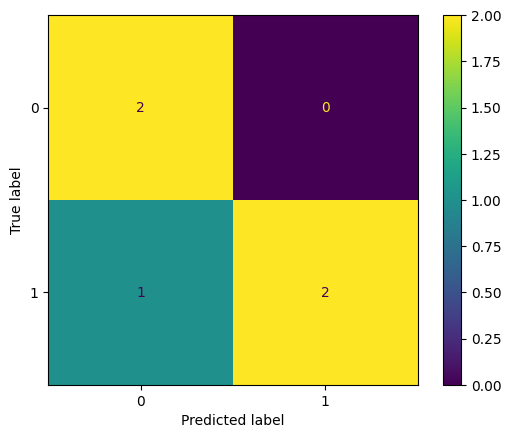

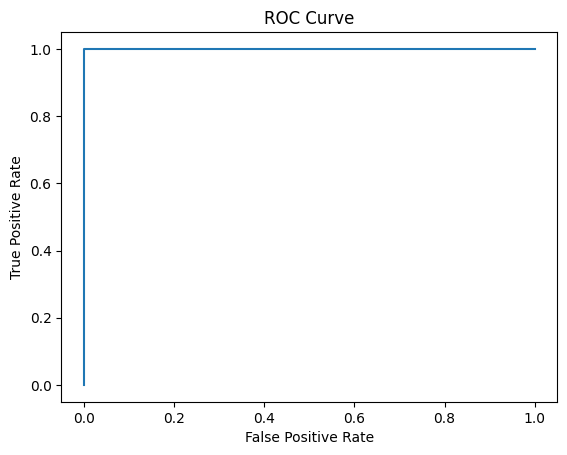

In [11]:
# Placeholder arrays; replace with real predictions and labels
# y_true and y_pred should be 1D arrays of class labels
# y_score should be probabilities for ROC-AUC if binary classification

y_true = np.array([0, 1, 1, 0, 1])
y_pred = np.array([0, 1, 0, 0, 1])
y_score = np.array([0.1, 0.9, 0.4, 0.2, 0.8])

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc = roc_auc_score(y_true, y_score)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)
print("ROC-AUC:", roc)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

fpr, tpr, _ = roc_curve(y_true, y_score)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

## 7. Regression Metrics (MAE, RMSE, $R^2$)
Compute regression metrics and visualize residuals to assess fit quality.

MAE: 0.18000000000000002
RMSE: 0.18439088914585774
R^2: 0.84375


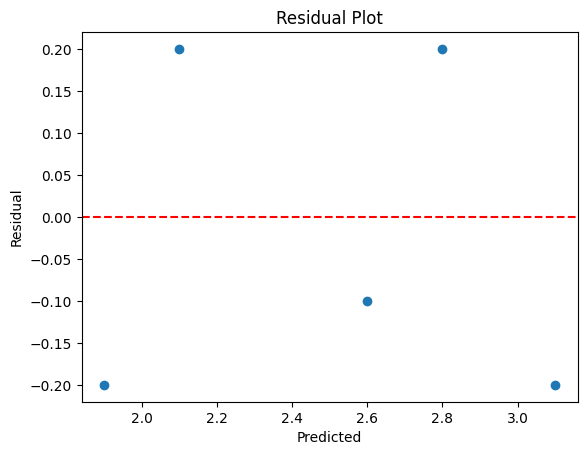

In [12]:
# Placeholder arrays; replace with real values

y_true_reg = np.array([2.3, 1.7, 3.0, 2.5, 2.9])
y_pred_reg = np.array([2.1, 1.9, 2.8, 2.6, 3.1])

mae = mean_absolute_error(y_true_reg, y_pred_reg)
rmse = mean_squared_error(y_true_reg, y_pred_reg, squared=False)
r2 = r2_score(y_true_reg, y_pred_reg)

print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)

residuals = y_true_reg - y_pred_reg
plt.scatter(y_pred_reg, residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

## 8. Ranking Metrics (MAP, NDCG)
If ranking outputs exist, compute MAP and NDCG from relevance labels and predicted scores.

In [13]:
# Example placeholder relevance list; replace with actual ranking outputs
relevance_lists = [
    [3, 2, 1, 0, 0],
    [2, 2, 0, 0, 0],
]

if mean_average_precision is not None:
    map_score = mean_average_precision(relevance_lists)
    print("MAP:", map_score)
else:
    print("mean_average_precision not available")

if ndcg_at_k is not None:
    ndcg = ndcg_at_k(relevance_lists[0], k=5)
    print("NDCG@5:", ndcg)
else:
    print("ndcg_at_k not available")

mean_average_precision not available
ndcg_at_k not available


## 9. Calibration and Threshold Analysis
Evaluate probability calibration, plot calibration curves, and analyze metric sensitivity across thresholds.

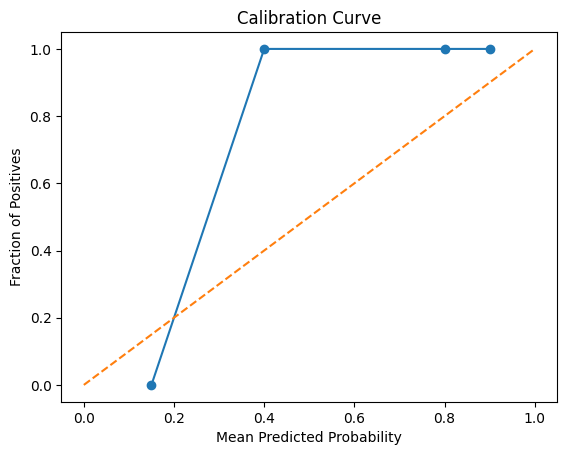

In [14]:
if "y_true" in globals() and "y_score" in globals():
    prob_true, prob_pred = calibration_curve(y_true, y_score, n_bins=5)
    plt.plot(prob_pred, prob_true, marker="o")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title("Calibration Curve")
    plt.show()

    thresholds = np.linspace(0.1, 0.9, 9)
    rows = []
    for t in thresholds:
        pred = (y_score >= t).astype(int)
        rows.append({
            "threshold": float(t),
            "precision": precision_score(y_true, pred),
            "recall": recall_score(y_true, pred),
            "f1": f1_score(y_true, pred),
        })

    pd.DataFrame(rows)
else:
    print("Define y_true and y_score before running calibration analysis.")

## 10. Statistical Significance Tests
Run statistical tests (e.g., paired t-test, Wilcoxon) to compare model variants on metric distributions.

In [15]:
# Placeholder arrays for per-query metric values from two systems
metric_a = np.array([0.40, 0.52, 0.33, 0.44, 0.61])
metric_b = np.array([0.38, 0.49, 0.35, 0.42, 0.59])

# Paired t-test
_t, p_t = stats.ttest_rel(metric_a, metric_b)
print("Paired t-test p-value:", p_t)

# Wilcoxon signed-rank test
_w, p_w = stats.wilcoxon(metric_a, metric_b)
print("Wilcoxon p-value:", p_w)

Paired t-test p-value: 0.183566860055276
Wilcoxon p-value: 0.125


## 11. Generate Evaluation Report Artifacts
Save metrics tables, plots, and test summaries to Module D for downstream review.

In [16]:
REPORT_DIR = MODULE_D_DIR / "reports"
REPORT_DIR.mkdir(exist_ok=True)


def get_metric(name):
    if name in globals():
        try:
            return float(globals()[name])
        except Exception:
            return None
    return None

metrics_summary = {
    "accuracy": get_metric("acc"),
    "precision": get_metric("prec"),
    "recall": get_metric("rec"),
    "f1": get_metric("f1"),
    "roc_auc": get_metric("roc"),
    "mae": get_metric("mae"),
    "rmse": get_metric("rmse"),
    "r2": get_metric("r2"),
}

summary_path = REPORT_DIR / "metrics_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, indent=2)

print("Saved:", summary_path)

Saved: D:\IUT SEMESTER 7\CLIR\CLIR-News-Retrieval-System\src\Module D — Ranking, Scoring, & Evaluation\reports\metrics_summary.json


## 12. Write the Notebook to `Module D/testing_evaluation.ipynb`
Use nbformat to programmatically assemble cells and save the notebook file into Module D.

In [17]:
# This cell demonstrates how to programmatically write a notebook file.
# It is not needed unless you want to regenerate a clean copy from code.

WRITE_NOTEBOOK = False
if WRITE_NOTEBOOK:
    nb = nbf.v4.new_notebook()
    nb.cells = [
        nbf.v4.new_markdown_cell("# Testing and Evaluation Notebook"),
        nbf.v4.new_markdown_cell("Generated programmatically with nbformat."),
    ]

    out_path = MODULE_D_DIR / "testing_evaluation.ipynb"
    with open(out_path, "w", encoding="utf-8") as f:
        nbf.write(nb, f)

    print("Wrote notebook to:", out_path)
else:
    print("Set WRITE_NOTEBOOK = True to regenerate the notebook file.")

Set WRITE_NOTEBOOK = True to regenerate the notebook file.
